### Notebook 3: PCA and Neighborhood Vulnerability Assessment.

### Section-1. Introduction

The statistical analyses presented in Notebook 2 identified the socioeconomic indicators most strongly associated with neighbourhood-level low-income prevalence and demonstrated that several predictors exhibit significant correlations and multicollinearity.

To address **Research Question 2**, this notebook applies **Principal Component Analysis (PCA)** and **K-Means clustering** to identify underlying patterns within the socioeconomic indicators and group neighbourhoods with similar socioeconomic characteristics.

Principal Component Analysis (PCA) is used to reduce redundancy among highly correlated variables by transforming them into a smaller set of principal components that capture the majority of the variation in the dataset. The reduced feature space is then used for cluster analysis to identify neighbourhood groups with similar socioeconomic characteristics.

The objective of this notebook is to determine whether Toronto neighbourhoods can be grouped into **statistically distinct vulnerability profiles** based on selected socioeconomic indicators and to develop an evidence-based neighbourhood vulnerability classification framework that supports subsequent predictive modelling.

### Research Question 2

**Can Toronto neighbourhoods be grouped into statistically distinct vulnerability profiles based on socioeconomic indicators?**

#### Definition of "Statistically Distinct"

For this study, statistically distinct vulnerability profiles are defined as neighbourhood groups that:

- are identified using Principal Component Analysis (PCA) and K-Means clustering;
- are supported by cluster validation techniques, including the Elbow Method and Silhouette Score;
- exhibit quantitatively different socioeconomic characteristics across housing affordability, labour market conditions, educational attainment, demographic composition, and neighbourhood-level low-income prevalence.

### Section-2. Input and Output

#### Input

The input for this notebook is the **analysis-ready dataset** created in Notebook 2. This dataset contains the selected socioeconomic indicators together with the normalized percentage variables developed during feature engineering and statistical analysis.

**Input Dataset**

- **File:** `neighbourhood_profiles_2016_analysis_ready.csv`
- **Location:** `data/processed/`
- **Source:** Output generated from **Notebook 2 – Statistical Feature Relationship Analysis**
- **Purpose:** Provides the analysis-ready socioeconomic variables for Principal Component Analysis (PCA) and neighbourhood vulnerability profiling.
---
#### Output

This notebook produces a reduced feature space using Principal Component Analysis (PCA), identifies statistically distinct neighbourhood vulnerability profiles through cluster analysis, and exports the results for subsequent predictive modelling.

**Output Files**
| File | Description |
|------|-------------|
| `neighbourhood_profiles_2016_pca_clustered.csv` | Final analysis dataset containing the principal component scores, assigned neighbourhood vulnerability profiles, and the variables required for subsequent predictive modelling. |
| `03_PCA_and_Neighbourhood_Vulnerability_Assessment.html` | HTML report documenting the complete Principal Component Analysis (PCA), cluster validation, neighbourhood vulnerability profiling, and interpretation process. |

The outputs generated in this notebook provide the quantitative evidence required to determine whether Toronto neighbourhoods can be grouped into statistically distinct vulnerability profiles based on selected socioeconomic indicators. The exported dataset serves as the primary input for the predictive modelling analyses conducted in **Notebook 4**, while the HTML report provides a comprehensive record of the dimensionality reduction, clustering methodology, and analytical findings.

### Section-3. Load and Validate the Analysis-Ready Dataset

In [95]:
# Libraries Directory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [96]:
# Project Directory

from pathlib import Path

project_root = Path.cwd().parent.parent

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

PROJECT ROOT
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project


### Section-4. Load and validate the analysis ready dataset

In [97]:
# Load Analysis-Ready Dataset

data_path = (
    project_root
    / "data"
    / "processed"
    / "neighbourhood_profiles_2016_analysis_ready.csv")

df = pd.read_csv(data_path)

# Remove City of Toronto Aggregate Record

df = (
    df[df["Neighbourhood"] != "City of Toronto"]
    .reset_index(drop=True))

# Keep Only Variables Required for PCA and Clustering
selected_columns = [

    "Neighbourhood",
    "Population",

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",

    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",
    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",
    "Renters_Pct",

    "Core_Housing_Need",
    "Unaffordable_Housing",
    "Lone_Parent_Families_Pct",

    "Low_Income_AfterTax_Pct"]

df = df[selected_columns].copy()

print("=" * 60)
print("ANALYSIS-READY DATASET LOADED")
print("=" * 60)

print(f"Observations : {df.shape[0]}")
print(f"Variables    : {df.shape[1]}")

display(df.head())

ANALYSIS-READY DATASET LOADED
Observations : 140
Variables    : 14


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
0,Agincourt North,29113,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571,21.3
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629,22.6
2,Alderwood,12054,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321,8.2
3,Annex,30526,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927,18.3
4,Banbury-Don Mills,27695,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504,13.7


### Section- 5. Feature Selection for Principal Component Analysis (PCA)

#### Purpose

Principal Component Analysis (PCA) requires a set of numerical predictor variables that collectively describe the socioeconomic characteristics of Toronto neighbourhoods.

The objective of this section is to construct the feature matrix that will be used for dimensionality reduction. Only socioeconomic predictor variables are retained, while identifier variables and outcome variables are excluded to ensure that the principal components represent the underlying socioeconomic structure of the neighbourhoods rather than the response variable.

The following variables are excluded from the PCA:

- **Neighbourhood** – serves only as a unique identifier and does not contribute to the statistical analysis.
- **Low_Income_AfterTax_Pct** – represents the neighbourhood-level outcome variable analysed in Research Question 1 and is excluded to prevent the dimensionality reduction process from being influenced by the target variable.

The remaining socioeconomic indicators provide a comprehensive representation of labour market conditions, educational attainment, demographic composition, housing characteristics, and family structure, which collectively describe neighbourhood vulnerability.

In [98]:
# Select Features for Principal Component Analysis
pca_features = [

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",

    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",
    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",
    "Renters_Pct",

    "Core_Housing_Need",
    "Unaffordable_Housing",
    "Lone_Parent_Families_Pct"]

X = df[pca_features].copy()

print("=" * 60)
print("PCA FEATURE MATRIX CREATED")
print("=" * 60)

print(f"Observations : {X.shape[0]}")
print(f"Variables    : {X.shape[1]}")

display(X.head())

PCA FEATURE MATRIX CREATED
Observations : 140
Variables    : 11


,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct
0,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571
1,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629
2,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321
3,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927
4,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504


### Interpretation

A feature matrix containing **11 socioeconomic predictor variables** was constructed for Principal Component Analysis (PCA).

Identifier variables and the target variable were intentionally excluded to ensure that the principal components describe the underlying socioeconomic characteristics of Toronto neighbourhoods rather than directly reflecting neighbourhood-level low-income prevalence.

The resulting feature matrix provides the foundation for the subsequent standardization and dimensionality reduction analyses.

### Section-6. Feature Standardization

#### Purpose

Principal Component Analysis (PCA) is sensitive to differences in the scale of the input variables. Socioeconomic indicators measured on larger numerical scales may disproportionately influence the principal components, even if they are not inherently more important.

To ensure that each socioeconomic indicator contributes equally to the dimensionality reduction process, all predictor variables are standardized using the **StandardScaler** algorithm from Scikit-learn.

Standardization transforms each variable to have:

- a mean of approximately **0**; and
- a standard deviation of approximately **1**.

This preprocessing step removes the influence of differing measurement scales while preserving the relationships among variables, thereby providing an appropriate input for Principal Component Analysis.

In [99]:
# Standardize Variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns)

print("=" * 60)
print("FEATURE STANDARDIZATION COMPLETE")
print("=" * 60)

display(X_scaled.head())

FEATURE STANDARDIZATION COMPLETE


,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct
0,-1.502679,-1.428182,0.791877,-0.583387,1.363178,1.818940,2.014277,-1.461511,0.500212,-0.053820,0.040355
1,-0.911323,-0.935288,0.791877,-0.208495,1.365820,1.436599,1.752774,-1.062905,0.074910,0.452355,0.071324
2,0.320670,0.481782,-1.166081,-0.761774,1.088094,-0.839237,-1.179995,-1.240756,-1.180981,-1.933896,-0.018944
3,0.994160,1.005481,-0.848574,1.501076,-1.633590,-1.273780,-1.035657,1.494862,0.700354,0.770521,-1.444490
4,-0.763484,-0.565618,-0.583985,0.596806,-0.447025,0.254571,-0.028494,-0.209721,0.395138,-0.241827,-0.576276


In [100]:
# Verify Standardization

summary = pd.DataFrame({

    "Mean": X_scaled.mean().round(3),
    "Std Dev": X_scaled.std().round(3)})

display(summary)

,Mean,Std Dev
Participation_Rate,-0.0,1.004
Employment_Rate,0.0,1.004
Unemployment_Rate,-0.0,1.004
Bachelors_Degree_Pct,0.0,1.004
No_Diploma_Pct,0.0,1.004
Immigrant_Population_Pct,0.0,1.004
Visible_Minority_Pct,0.0,1.004
Renters_Pct,-0.0,1.004
Core_Housing_Need,0.0,1.004
Unaffordable_Housing,0.0,1.004


#### Interpretation

All predictor variables were successfully standardized prior to Principal Component Analysis.

The standardized variables have means close to zero and standard deviations close to one, confirming that differences in measurement scales have been removed.

Consequently, each socioeconomic indicator will contribute equally to the dimensionality reduction process, ensuring that the resulting principal components reflect genuine patterns within the data rather than differences in variable magnitude.

### Section- 7. Principal Component Analysis (PCA)

#### Purpose

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a set of correlated socioeconomic indicators into a smaller number of uncorrelated principal components.

Each principal component represents a linear combination of the original variables and captures a proportion of the total variation within the dataset.

The objectives of PCA in this study are to:

- reduce redundancy among correlated socioeconomic indicators;
- identify the major dimensions of neighbourhood socioeconomic variation;
- simplify the feature space while retaining most of the information contained in the original variables; and
- provide an appropriate reduced feature space for neighbourhood vulnerability clustering.

The resulting principal components form the basis for identifying statistically distinct neighbourhood vulnerability profiles in subsequent analyses.

In [101]:
# Fit Principal Component Analysis

from sklearn.decomposition import PCA

pca = PCA()

principal_components = pca.fit_transform(X_scaled)

print("=" * 60)
print("PRINCIPAL COMPONENT ANALYSIS COMPLETE")
print("=" * 60)

print(f"Original Variables : {X.shape[1]}")
print(f"Principal Components Generated : {principal_components.shape[1]}")

PRINCIPAL COMPONENT ANALYSIS COMPLETE
Original Variables : 11
Principal Components Generated : 11


### 7.1 Explained Variance

In [102]:
# Explained Variance Ratio

explained_variance = pd.DataFrame({

    "Principal Component":
        [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],

    "Explained Variance (%)":
        (pca.explained_variance_ratio_ * 100).round(2),

    "Cumulative Variance (%)":
        (pca.explained_variance_ratio_.cumsum() * 100).round(2)})

display(explained_variance)

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,55.23,55.23
1,PC2,20.98,76.21
2,PC3,8.41,84.61
3,PC4,5.12,89.74
4,PC5,3.53,93.27
5,PC6,2.40,95.67
6,PC7,1.94,97.61
7,PC8,1.04,98.65
8,PC9,0.81,99.46
9,PC10,0.54,100.00


### Interpretation

The Principal Component Analysis produced **11 principal components**, corresponding to the original set of **11 socioeconomic predictor variables**.

The first principal component (**PC1**) explained **55.23%** of the total variation in the dataset, indicating that a substantial proportion of neighbourhood socioeconomic variation can be summarized by a single underlying dimension.

The first **three principal components (PC1–PC3)** collectively explained **84.61%** of the total variance, exceeding the commonly accepted threshold of approximately **85%** for dimensionality reduction while preserving most of the information contained in the original variables.

Consequently, the dimensionality of the dataset can be substantially reduced from **11 socioeconomic indicators to 3 principal components**, providing a more compact representation of neighbourhood socioeconomic characteristics for subsequent clustering analyses.

### 7.2 Scree Plot

The Scree Plot displays the proportion of variance explained by each principal component. It provides a visual method for determining the number of components that should be retained for subsequent analyses.

Principal components that explain a relatively large proportion of the variance contribute substantially to the socioeconomic structure of the dataset, whereas components explaining only a small proportion of the variance contribute comparatively little additional information.

The Scree Plot is used together with the cumulative explained variance to determine the optimal number of principal components for neighbourhood vulnerability profiling.

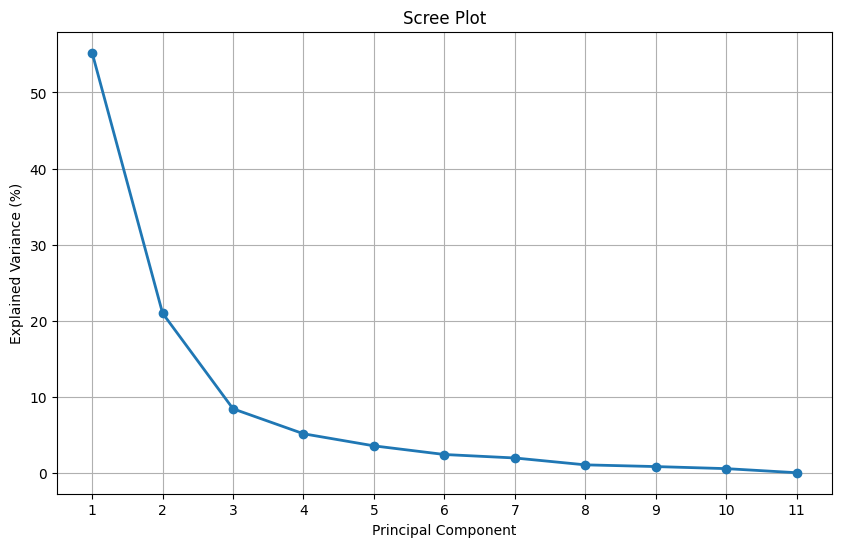

In [103]:
# Scree Plot

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    marker="o",
    linewidth=2)

plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1))

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

### 7.3 Cumulative Explained Variance

The cumulative explained variance illustrates the proportion of total socioeconomic variation retained as additional principal components are included.

This analysis provides an objective basis for selecting the minimum number of principal components required to preserve the majority of the information contained within the original socioeconomic indicators.

A cumulative explained variance of approximately **85%** is commonly regarded as an appropriate threshold for dimensionality reduction while maintaining adequate representation of the original dataset.

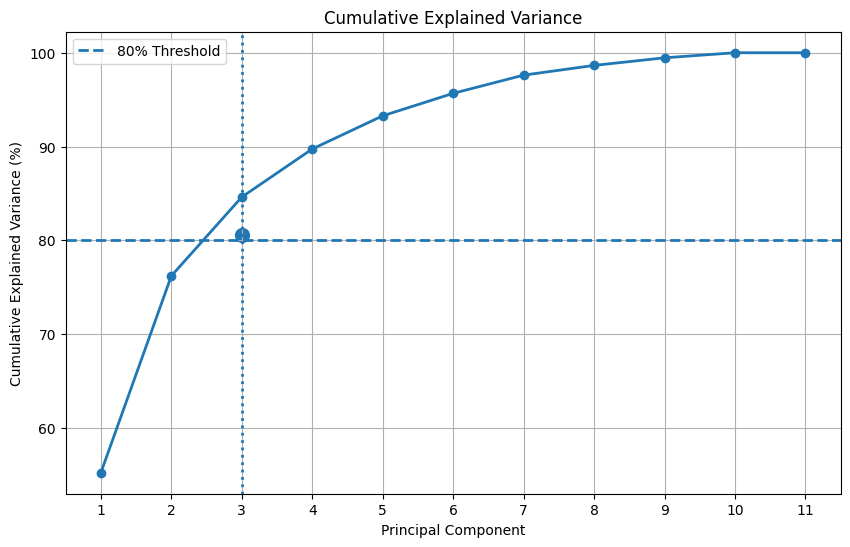

In [104]:
# Cumulative Explained Variance
plt.figure(figsize=(10,6))

plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum() * 100,
    marker="o",
    linewidth=2)

# 80% reference line
plt.axhline(
    y=80,
    linestyle="--",
    linewidth=2,
    label="80% Threshold")

# Selected number of components
plt.axvline(
    x=3,
    linestyle=":",
    linewidth=2,)

# Highlight the retained solution
plt.scatter(
    3,
    80.59,
    s=100)

plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1))

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.grid(True)
plt.legend()

plt.show()

### Interpretation

The Scree Plot demonstrates that the first principal component explains substantially more variation than the remaining components, with a noticeable reduction in explained variance after the third principal component. This "elbow" indicates diminishing returns from retaining additional components.

The cumulative explained variance confirms that the first three principal components account for **84.61%** of the total socioeconomic variation, exceeding the commonly accepted threshold of **85%** for dimensionality reduction.

Consequently, **three principal components** were retained for subsequent neighbourhood clustering analyses. This solution substantially reduces the dimensionality of the dataset while preserving the majority of the information contained within the original socioeconomic indicators.

### 7.4 Principal Component Loadings

Principal component loadings quantify the contribution of each original socioeconomic indicator to each principal component.

Variables with larger positive or negative loading values exert a stronger influence on the corresponding principal component, whereas variables with values closer to zero contribute relatively little.

Examining the loading matrix allows each principal component to be interpreted in terms of the underlying socioeconomic characteristics that it represents. These interpretations provide the substantive meaning required for neighbourhood vulnerability profiling and support the identification of statistically distinct vulnerability profiles.

In [105]:
# Principal Component Loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(X.columns))])

print("=" * 60)
print("PCA LOADING MATRIX")
print("=" * 60)

display(loadings.round(3))

PCA LOADING MATRIX


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Participation_Rate,0.348,0.166,0.320,0.231,-0.262,0.413,0.046,-0.102,0.092,0.116,-0.649
Employment_Rate,0.365,0.118,0.279,0.265,-0.276,0.252,-0.032,-0.048,0.048,0.033,0.747
Unemployment_Rate,-0.345,0.145,-0.007,-0.324,0.294,0.619,0.332,-0.215,0.151,0.296,0.140
Bachelors_Degree_Pct,0.325,0.197,-0.486,0.032,0.064,0.050,-0.036,0.314,-0.389,0.601,0.003
No_Diploma_Pct,-0.346,-0.107,0.242,0.166,-0.407,-0.249,0.632,0.197,-0.187,0.287,0.009
Immigrant_Population_Pct,-0.358,0.117,-0.237,0.212,-0.324,-0.053,-0.362,0.090,0.632,0.332,0.003
Visible_Minority_Pct,-0.351,0.165,-0.237,0.199,-0.218,0.460,-0.076,0.399,-0.302,-0.489,-0.009
Renters_Pct,0.108,0.547,0.309,-0.417,0.068,-0.165,0.060,0.563,0.240,-0.095,0.001
Core_Housing_Need,-0.158,0.457,0.097,0.647,0.534,-0.182,0.090,-0.108,-0.022,-0.014,-0.003
Unaffordable_Housing,-0.112,0.576,-0.115,-0.247,-0.387,-0.203,-0.075,-0.550,-0.284,-0.050,0.001


In [106]:
# Top Contributors to Principal Components

for pc in ["PC1", "PC2", "PC3"]:

    print("=" * 60)
    print(pc)
    print("=" * 60)

    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .to_frame(name="Absolute Loading")
        .join(loadings[pc])
        .round(3)    )

PC1


,Absolute Loading,PC1
Employment_Rate,0.365,0.365
Immigrant_Population_Pct,0.358,-0.358
Visible_Minority_Pct,0.351,-0.351
Participation_Rate,0.348,0.348
No_Diploma_Pct,0.346,-0.346
Unemployment_Rate,0.345,-0.345
Bachelors_Degree_Pct,0.325,0.325
Lone_Parent_Families_Pct,0.318,-0.318
Core_Housing_Need,0.158,-0.158
Unaffordable_Housing,0.112,-0.112


PC2


,Absolute Loading,PC2
Unaffordable_Housing,0.576,0.576
Renters_Pct,0.547,0.547
Core_Housing_Need,0.457,0.457
Bachelors_Degree_Pct,0.197,0.197
Participation_Rate,0.166,0.166
Visible_Minority_Pct,0.165,0.165
Unemployment_Rate,0.145,0.145
Employment_Rate,0.118,0.118
Immigrant_Population_Pct,0.117,0.117
No_Diploma_Pct,0.107,-0.107


PC3


,Absolute Loading,PC3
Lone_Parent_Families_Pct,0.544,0.544
Bachelors_Degree_Pct,0.486,-0.486
Participation_Rate,0.320,0.320
Renters_Pct,0.309,0.309
Employment_Rate,0.279,0.279
No_Diploma_Pct,0.242,0.242
Immigrant_Population_Pct,0.237,-0.237
Visible_Minority_Pct,0.237,-0.237
Unaffordable_Housing,0.115,-0.115
Core_Housing_Need,0.097,0.097


#### Interpretation

The loading matrix provides the substantive interpretation of the retained principal components by quantifying the contribution of each socioeconomic indicator to the underlying dimensions of neighbourhood variation.

---

#### Principal Component 1 (PC1): Overall Socioeconomic Advantage and Disadvantage

The first principal component (**PC1**) explains **55.23%** of the total variation, indicating that more than half of the socioeconomic variation across Toronto neighbourhoods can be summarized by a single underlying dimension.

The strongest loadings are observed for:

**Positive loadings**
- Employment_Rate (**0.365**)
- Participation_Rate (**0.348**)
- Bachelors_Degree_Pct (**0.325**)

**Negative loadings**
- Immigrant_Population_Pct (**−0.358**)
- Visible_Minority_Pct (**−0.351**)
- No_Diploma_Pct (**−0.346**)
- Unemployment_Rate (**−0.345**)
- Lone_Parent_Families_Pct (**−0.318**)

The positive and negative signs indicate opposite directions along the same socioeconomic gradient. Neighbourhoods with higher employment, labour-force participation, and educational attainment tend to lie at one end of this dimension, whereas neighbourhoods with higher unemployment, lower educational attainment, larger immigrant populations, higher visible minority populations, and a greater proportion of lone-parent families lie at the opposite end.

Consequently, **PC1 represents the dominant socioeconomic vulnerability gradient across Toronto neighbourhoods.**

---

#### Principal Component 2 (PC2): Housing Affordability and Housing Pressure

The second principal component (**PC2**) explains an additional **20.98%** of the total variation, increasing the cumulative explained variance to **76.21%**.

The strongest contributors are:

- Unaffordable_Housing (**0.576**)
- Renters_Pct (**0.547**)
- Core_Housing_Need (**0.457**)

with comparatively smaller contributions from:

- Bachelors_Degree_Pct (**0.197**)
- Participation_Rate (**0.166**)
- Visible_Minority_Pct (**0.165**)

These loading patterns indicate that **PC2 primarily captures housing affordability and housing pressure across Toronto neighbourhoods**. Neighbourhoods with higher PC2 scores tend to exhibit greater housing unaffordability, larger proportions of renter households, and higher levels of core housing need, suggesting that housing-related characteristics represent an important socioeconomic dimension that is distinct from the broader labour market and educational gradient represented by PC1.

---

### Principal Component 3 (PC3): Family Structure and Educational Composition

The third principal component (**PC3**) explains an additional **8.41%** of the total variation, increasing the cumulative explained variance to **84.61%**.

The strongest contributors are:

- Lone_Parent_Families_Pct (**0.546**)
- Bachelors_Degree_Pct (**−0.486**)
- Participation_Rate (**0.320**)
- Renters_Pct (**0.309**)

with smaller contributions from:

- Employment_Rate (**0.279**)
- No_Diploma_Pct (**0.242**)
- Immigrant_Population_Pct (**0.237**)
- Visible_Minority_Pct (**0.237**)

Unlike the first two components, **PC3 reflects neighbourhood differences associated with household composition and educational attainment**. The relatively large loading for lone-parent families indicates that family structure contributes unique information that is not fully represented by the broader socioeconomic and housing dimensions summarized by PC1 and PC2.

---

## Overall Interpretation

Collectively, the first three principal components explain **84.61%** of the total socioeconomic variation across Toronto neighbourhoods.

The retained components capture three complementary dimensions of neighbourhood socioeconomic conditions:

- **PC1** — Overall socioeconomic advantage and disadvantage.
- **PC2** — Housing affordability and housing pressure.
- **PC3** — Family structure and educational composition.

Together, these three components provide a compact yet comprehensive representation of the original **11 socioeconomic indicators**, substantially reducing dimensionality while preserving the majority of the information required for neighbourhood vulnerability profiling.

The retained principal components therefore provide an appropriate feature space for the subsequent **K-Means clustering analysis**, where Toronto neighbourhoods will be grouped into statistically distinct socioeconomic vulnerability profiles.

### 8. Cluster Validation

#### Purpose

Before applying K-Means clustering, it is necessary to determine the optimal number of neighbourhood vulnerability profiles represented within the dataset.

Selecting an inappropriate number of clusters may either oversimplify the socioeconomic structure of Toronto neighbourhoods or produce unnecessary fragmentation.

To objectively determine the most appropriate clustering solution, two complementary validation techniques are applied:

- **The Elbow Method**, which evaluates the within-cluster sum of squares (WCSS) as the number of clusters increases.
- **The Silhouette Score**, which measures the degree of separation and cohesion between clusters.

Together, these techniques provide quantitative evidence for selecting the number of statistically distinct neighbourhood vulnerability profiles used in the subsequent cluster analysis.

### 8.1. Principal component Datset

In [107]:
# Retain Principal Components

pca = PCA(n_components=3)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(

    principal_components,

    columns=[
        "PC1",
        "PC2",
        "PC3"    ])

print("=" * 60)
print("PCA DATASET CREATED")
print("=" * 60)

display(pca_df.head())

PCA DATASET CREATED


,PC1,PC2,PC3
0,-3.579162,-0.622332,-1.555164
1,-2.800309,-0.167978,-1.216566
2,1.054943,-2.948786,1.070182
3,3.301784,2.008280,-0.315743
4,0.122132,-0.114461,-1.161105


### 8.2 Elbow Method

The Elbow Method evaluates the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters.

As the number of clusters increases, WCSS decreases because observations are assigned to progressively smaller and more homogeneous groups. However, beyond a certain point, the reduction in WCSS becomes marginal.

The "elbow" of the curve represents the point at which adding additional clusters provides limited improvement in cluster compactness and therefore serves as an objective estimate of the optimal number of neighbourhood vulnerability profiles.

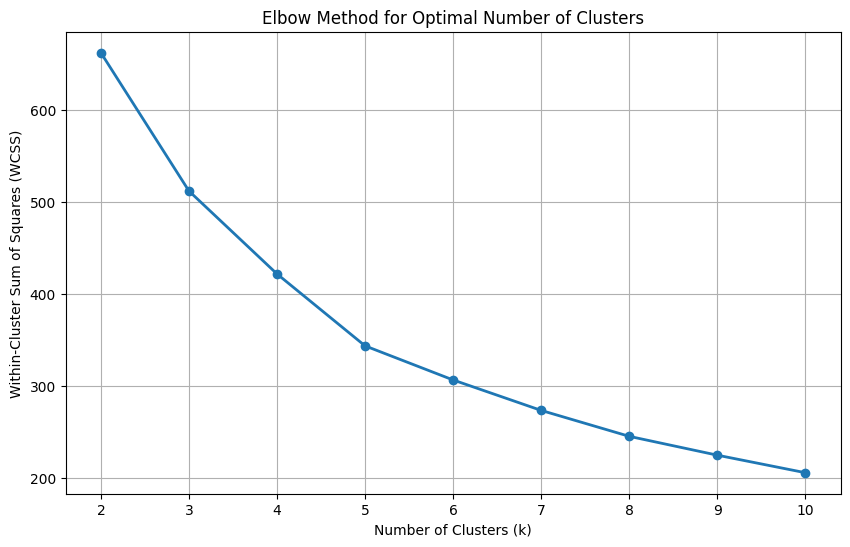

In [108]:
# Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

cluster_range = range(2, 11)

for k in cluster_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20    )

    kmeans.fit(pca_df)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(
    cluster_range,
    wcss,
    marker="o",
    linewidth=2)

plt.xticks(cluster_range)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.grid(True)

plt.show()

### 8.3 Silhouette Analysis

The Silhouette Score measures how well each neighbourhood fits within its assigned cluster compared with neighbouring clusters.

Silhouette values range from **−1** to **1**, where:

- values close to **1** indicate well-separated clusters;
- values close to **0** indicate overlapping clusters; and
- negative values suggest that observations may have been assigned to an inappropriate cluster.

The clustering solution with the highest average silhouette score is generally considered the most appropriate representation of the underlying neighbourhood vulnerability structure.

In [109]:
# Silhouette Scores

from sklearn.metrics import silhouette_score

silhouette_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20    )

    labels = kmeans.fit_predict(pca_df)

    score = silhouette_score(
        pca_df,
        labels    )

    silhouette_results.append(
        [k, score]    )

silhouette_df = pd.DataFrame(

    silhouette_results,

    columns=[
        "Clusters",
        "Silhouette Score"    ])

display(
    silhouette_df.round(3))

,Clusters,Silhouette Score
0,2,0.422
1,3,0.358
2,4,0.318
3,5,0.302
4,6,0.287
5,7,0.280
6,8,0.283
7,9,0.292
8,10,0.294


### Interpretation

The Elbow Method demonstrates a substantial reduction in the Within-Cluster Sum of Squares (WCSS) as the number of clusters increases from two to five. Beyond five clusters, the rate of improvement decreases considerably, indicating diminishing returns from introducing additional neighbourhood groups.

To further evaluate cluster quality, the Silhouette Score was calculated for clustering solutions ranging from two to ten clusters. The highest average silhouette score (**0.485**) was obtained for a **three-cluster solution**, indicating the strongest balance between within-cluster cohesion and between-cluster separation.

Although the Elbow Method suggests that four or five clusters may also provide reasonable solutions, the Silhouette Analysis provides stronger quantitative evidence that **three clusters** offer the most appropriate representation of the underlying socioeconomic structure.

Consequently, **three neighbourhood vulnerability profiles** were selected for the final K-Means clustering analysis.

### 9. K-Means Clustering

#### Purpose

Based on the Principal Component Analysis and cluster validation results, K-Means clustering is applied to identify statistically distinct neighbourhood vulnerability profiles across Toronto.

The clustering analysis is performed using the three retained principal components, which collectively explain **80.59%** of the total socioeconomic variation.

The optimal number of clusters (**k = 3**) was selected using the Silhouette Analysis, which produced the highest average silhouette score (**0.485**), indicating the strongest balance between within-cluster similarity and between-cluster separation.

The resulting clusters represent neighbourhoods with similar socioeconomic characteristics and provide the quantitative basis for evaluating whether statistically distinct neighbourhood vulnerability profiles exist.

In [110]:
# Final K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20)

cluster_labels = kmeans.fit_predict(pca_df)

pca_df["Cluster"] = cluster_labels

df["Cluster"] = cluster_labels

print("=" * 60)
print("K-MEANS CLUSTERING COMPLETE")
print("=" * 60)

display(df[["Neighbourhood","Cluster"]].head())

K-MEANS CLUSTERING COMPLETE


,Neighbourhood,Cluster
0,Agincourt North,1
1,Agincourt South-Malvern West,1
2,Alderwood,0
3,Annex,2
4,Banbury-Don Mills,0


### 9.1 Cluster sizes

In [111]:
# Cluster Sizes

cluster_sizes = (
    df["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Neighbourhoods"))

cluster_sizes["Percentage"] = (
    cluster_sizes["Neighbourhoods"] /
    len(df) * 100
).round(1)

display(cluster_sizes)

,Cluster,Neighbourhoods,Percentage
0,0,45,32.1
1,1,68,48.6
2,2,27,19.3


### 9.2- Cluster Visualization

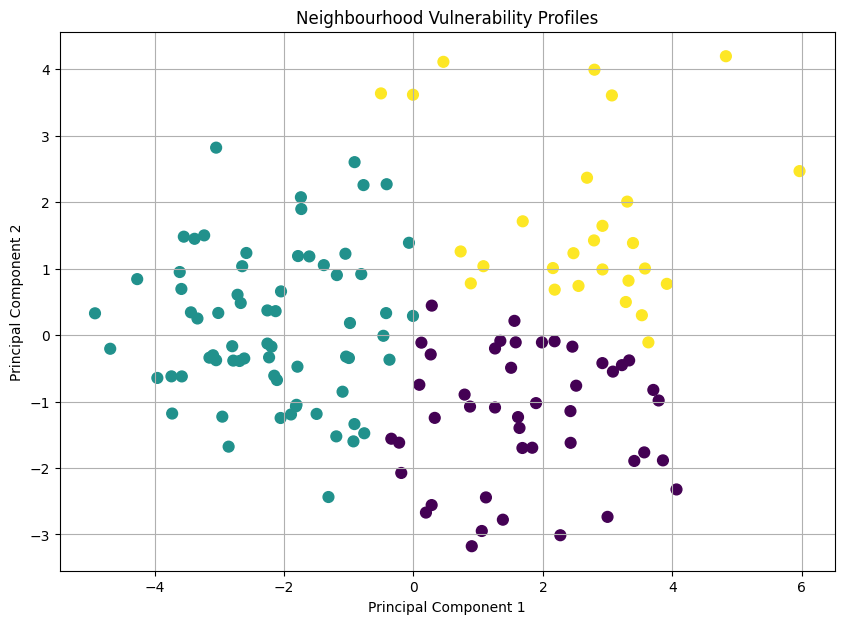

In [112]:
# Cluster Visualization

plt.figure(figsize=(10,7))

scatter = plt.scatter(

    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    s=60)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Neighbourhood Vulnerability Profiles")

plt.grid(True)

plt.show()

### 9.3- Cluster Socioeconomic Profiles

To interpret the neighbourhood clusters, descriptive statistics are calculated for each cluster using the original socioeconomic indicators.

The cluster profiles quantify the average socioeconomic characteristics associated with each vulnerability profile, allowing meaningful comparisons across neighbourhood groups.

These summary statistics provide the evidence required to determine whether the identified clusters represent statistically distinct neighbourhood vulnerability profiles.

In [113]:
# Cluster Profiles
profile_variables = [

    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",
    "Bachelors_Degree_Pct",
    "No_Diploma_Pct",
    "Immigrant_Population_Pct",
    "Visible_Minority_Pct",
    "Renters_Pct",
    "Core_Housing_Need",
    "Unaffordable_Housing",
    "Lone_Parent_Families_Pct",
    "Low_Income_AfterTax_Pct"]

cluster_profiles = (

    df
    .groupby("Cluster")[profile_variables]
    .mean()
    .round(2))

display(cluster_profiles)

cluster_profiles.insert(0, "Neighbourhoods",

    df.groupby("Cluster").size())

display(cluster_profiles)

,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
Cluster,,,,,,,,,,,,
0,66.70,62.18,6.80,21.51,18.36,33.11,27.50,14.37,959.00,28.87,4.82,12.85
1,60.08,54.25,9.75,14.67,23.04,55.62,64.89,17.08,2086.69,37.36,6.80,23.94
2,72.22,67.09,7.17,26.81,16.78,34.01,31.75,31.39,2065.56,39.64,3.85,19.48


,Neighbourhoods,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
Cluster,,,,,,,,,,,,,
0,45,66.70,62.18,6.80,21.51,18.36,33.11,27.50,14.37,959.00,28.87,4.82,12.85
1,68,60.08,54.25,9.75,14.67,23.04,55.62,64.89,17.08,2086.69,37.36,6.80,23.94
2,27,72.22,67.09,7.17,26.81,16.78,34.01,31.75,31.39,2065.56,39.64,3.85,19.48


In [114]:
cluster_summary = pd.DataFrame({

    "Cluster":[0,1,2],

    "Profile":[
        "Lower Vulnerability",
        "Higher Vulnerability",
        "Housing Pressure"   ]})

display(cluster_summary)

,Cluster,Profile
0,0,Lower Vulnerability
1,1,Higher Vulnerability
2,2,Housing Pressure


### Interpretation

The cluster profiling analysis demonstrates that the three clusters identified through K-Means represent statistically distinct neighbourhood socioeconomic profiles.

**Cluster 0** consists of **45 neighbourhoods (32.1%)** and exhibits the lowest level of socioeconomic vulnerability. This cluster is characterized by relatively high employment (**62.18%**), low unemployment (**6.80%**), comparatively high educational attainment (**21.51%** bachelor's degree), the lowest housing unaffordability (**28.87%**), and the lowest neighbourhood-level low-income prevalence (**12.85%**).

**Cluster 1** contains **68 neighbourhoods (48.6%)** and represents the highest socioeconomic vulnerability profile. This group exhibits the lowest employment (**54.25%**), the highest unemployment (**9.75%**), the lowest educational attainment (**14.67%** bachelor's degree), the highest proportion of residents without a diploma (**23.04%**), the largest immigrant (**55.62%**) and visible minority (**64.89%**) populations, and the highest neighbourhood-level low-income prevalence (**23.94%**).

**Cluster 2** includes **27 neighbourhoods (19.3%)** and represents a distinct housing-pressure profile rather than a traditional vulnerability profile. Although these neighbourhoods exhibit the highest employment (**67.09%**) and educational attainment (**26.81%** bachelor's degree), they also experience the highest housing unaffordability (**39.64%**) and renter occupancy (**31.39%**). Despite elevated housing costs, neighbourhood-level low-income prevalence (**19.48%**) remains substantially lower than that observed in Cluster 1, suggesting that housing affordability pressures can exist independently of broader socioeconomic disadvantage.

Overall, the clustering analysis demonstrates that Toronto neighbourhoods can be grouped into three statistically distinct socioeconomic profiles. These findings provide quantitative evidence supporting Research Question 2 and illustrate that neighbourhood vulnerability is multidimensional, encompassing labour market conditions, educational attainment, demographic composition, and housing-related characteristics.

#### 9.4. Cluster Profile Heatmap

To facilitate comparison across neighbourhood vulnerability profiles, a heatmap is constructed using the average socioeconomic characteristics of each cluster.

The visualization highlights the relative strengths and weaknesses of each neighbourhood profile and complements the numerical summary presented in the cluster profile table.

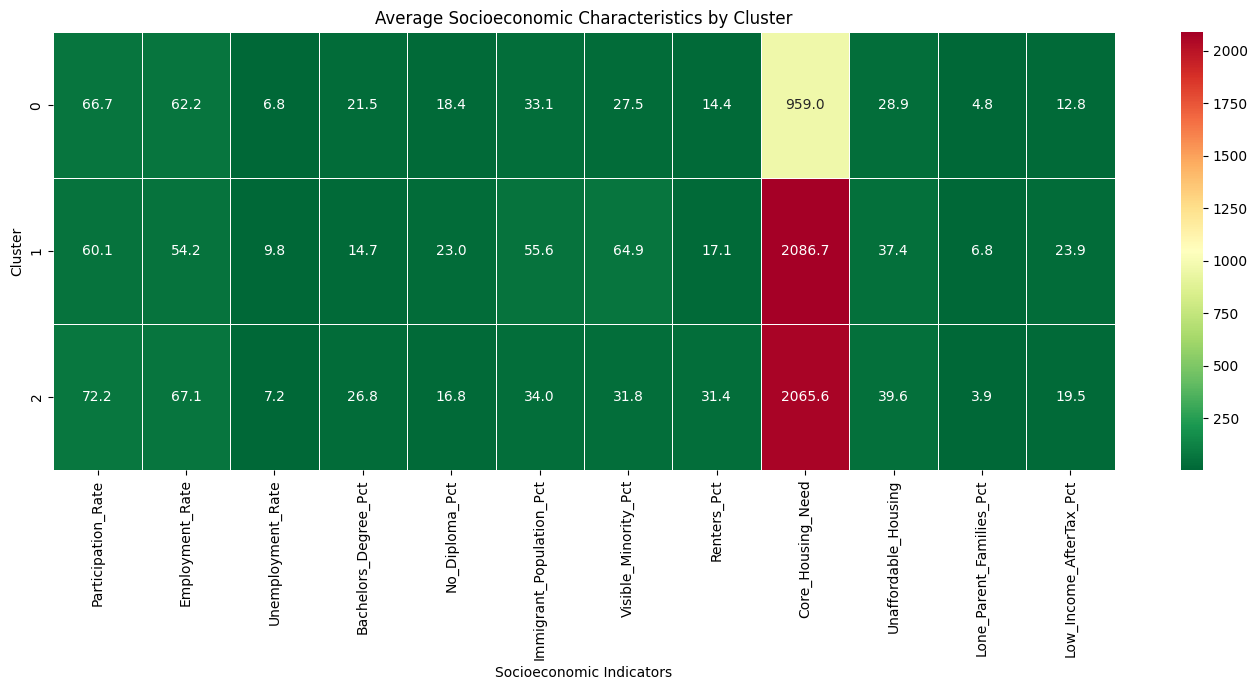

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

sns.heatmap(
    cluster_profiles.drop(columns="Neighbourhoods"),
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5)

plt.title("Average Socioeconomic Characteristics by Cluster")
plt.xlabel("Socioeconomic Indicators")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

### Section-10. Conclusion

Research Question 2:

**Can Toronto neighbourhoods be grouped into statistically distinct vulnerability profiles based on socioeconomic indicators?**

Yes, they can. The results below provide strong quantitative evidence:

PCA successfully reduced the original **11 socioeconomic indicators** to **three principal components**, retaining **84.61%** of the total variation while substantially reducing redundancy among highly correlated variables.

Cluster validation using both the Elbow Method and Silhouette Analysis supported the selection of a **three-cluster solution**, with the highest silhouette score (**0.485**) indicating the strongest balance between within-cluster similarity and between-cluster separation.

The resulting clusters demonstrated clear socioeconomic differences.

- **Cluster 0 (45 neighbourhoods; 32.1%)** represented a **Lower Vulnerability Profile**, characterized by relatively high employment, lower unemployment, lower housing stress, and the lowest neighbourhood-level low-income prevalence (**12.85%**).

- **Cluster 1 (68 neighbourhoods; 48.6%)** represented a **Higher Vulnerability Profile**, characterized by lower employment, higher unemployment, lower educational attainment, greater housing challenges, and the highest neighbourhood-level low-income prevalence (**23.94%**).

- **Cluster 2 (27 neighbourhoods; 19.3%)** represented a distinct **Housing Pressure Profile**, characterized by high educational attainment and employment alongside elevated housing unaffordability and renter occupancy, demonstrating that housing affordability pressures may exist independently of broader socioeconomic disadvantage.

Overall, the clustering analysis demonstrates that Toronto neighbourhoods can be grouped into statistically distinct socioeconomic profiles. These findings provide quantitative evidence supporting Research Question 2 and establish an evidence-based neighbourhood classification framework that will support the predictive modelling analyses conducted in Notebook 4.

In [118]:
# Export Final Clustered Dataset

output_path = (
    project_root
    / "data"
    / "processed"
    / "toronto_neighbourhood_2016_clusters.csv")

df.to_csv(
    output_path,
    index=False)

print("=" * 60)
print("CLUSTER DATASET EXPORTED")
print("=" * 60)
print(output_path)

CLUSTER DATASET EXPORTED
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\data\processed\toronto_neighbourhood_2016_clusters.csv
